In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_train=pd.read_csv('train.csv')
df_test=pd.read_csv('test.csv')
df_stores=pd.read_csv('stores.csv')
df_features=pd.read_csv('features.csv')

In [3]:
df_train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [4]:
df_stores.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [5]:
df_features.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [6]:
df_train = df_train.merge(df_features, on=['Store', 'Date', 'IsHoliday'], how='left')
df_train = df_train.merge(df_stores, on=['Store'], how='left')

In [7]:
df_test = df_test.merge(df_features, on=['Store', 'Date', 'IsHoliday'], how='left')
df_test = df_test.merge(df_stores, on=['Store'], how='left')

In [8]:
print("Train Date Type:", df_train['Date'].dtype)
print("Test Date Type:", df_test['Date'].dtype)

Train Date Type: object
Test Date Type: object


In [9]:
df_train['Date'] = pd.to_datetime(df_train['Date'])
df_test['Date'] = pd.to_datetime(df_test['Date'])

In [10]:
df_train['Year'] = df_train['Date'].dt.year
df_train['Month'] = df_train['Date'].dt.month
df_train['Week'] = df_train['Date'].dt.isocalendar().week.astype(int)

In [11]:
df_train.shape

(421570, 19)

In [12]:
df_test['Year'] = df_test['Date'].dt.year
df_test['Month'] = df_test['Date'].dt.month
df_test['Week'] = df_test['Date'].dt.isocalendar().week.astype(int)

In [13]:
df_train.isnull().sum()

,0
Store,0
Dept,0
Date,0
Weekly_Sales,0
IsHoliday,0
Temperature,0
Fuel_Price,0
MarkDown1,270889
MarkDown2,310322
MarkDown3,284479


In [14]:
df_test.isna().sum()

,0
Store,0
Dept,0
Date,0
IsHoliday,0
Temperature,0
Fuel_Price,0
MarkDown1,149
MarkDown2,28627
MarkDown3,9829
MarkDown4,12888


In [15]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 19 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Temperature   421570 non-null  float64       
 6   Fuel_Price    421570 non-null  float64       
 7   MarkDown1     150681 non-null  float64       
 8   MarkDown2     111248 non-null  float64       
 9   MarkDown3     137091 non-null  float64       
 10  MarkDown4     134967 non-null  float64       
 11  MarkDown5     151432 non-null  float64       
 12  CPI           421570 non-null  float64       
 13  Unemployment  421570 non-null  float64       
 14  Type          421570 non-null  object        
 15  Size          421

<Axes: xlabel='Weekly_Sales'>

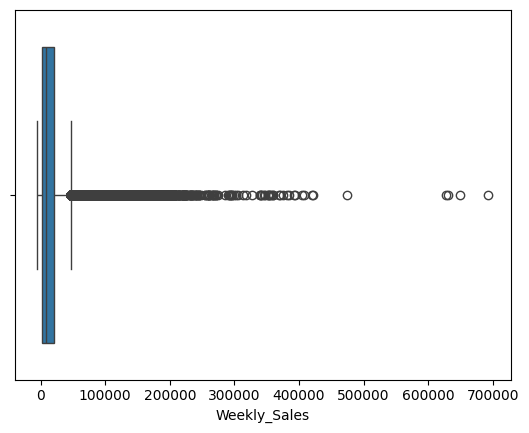

In [16]:
sns.boxplot(data=df_train, x='Weekly_Sales')

In [17]:
cutoff = df_train['Weekly_Sales'].quantile(0.99)

In [18]:
outliers = df_train[df_train['Weekly_Sales'] > cutoff]

In [19]:
len(outliers)

4216

In [20]:
# Months having most outliers
df_train[df_train['Weekly_Sales'] > cutoff]['Month'].value_counts().sort_index()

,count
Month,
1,206
2,400
3,357
4,375
5,291
6,324
7,345
8,350
9,329


In [21]:
# See how many outliers occur during normal weeks (False) vs. holiday weeks (True)
df_train[df_train['Weekly_Sales'] > cutoff]['IsHoliday'].value_counts()

,count
IsHoliday,
False,3820
True,396


Holiday weeks make up less than 8% of the year, but they create nearly 10% of the biggest sales spikes.

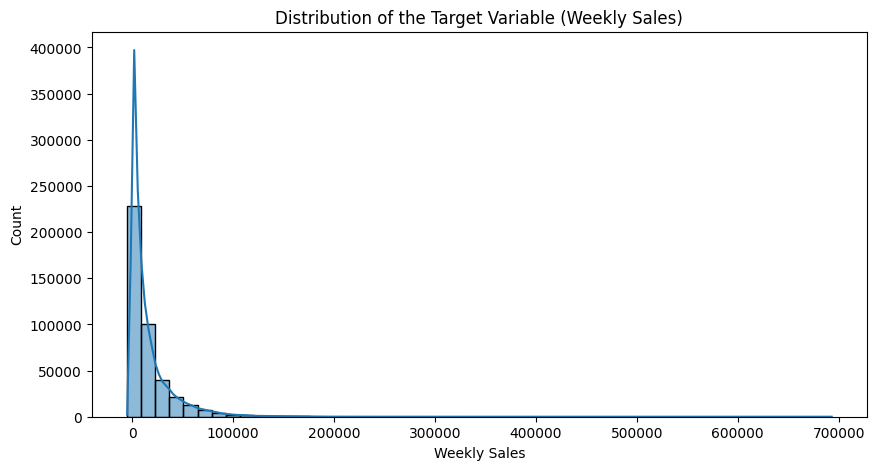

In [22]:
plt.figure(figsize=(10, 5))
sns.histplot(df_train['Weekly_Sales'], bins=50, kde=True)
plt.title('Distribution of the Target Variable (Weekly Sales)')
plt.xlabel('Weekly Sales')
plt.show()

In [23]:
(df_train['Weekly_Sales'] < 0).sum()

np.int64(1285)

The dataset contains a small number of negative values in the Weekly_Sales column, which represent financial entries where customer returns and refunds exceeded the total sales for that department in a given week.
As these values are very small portion of the dataset I am dropping them.

In [24]:
df_train = df_train[df_train['Weekly_Sales'] >= 0]

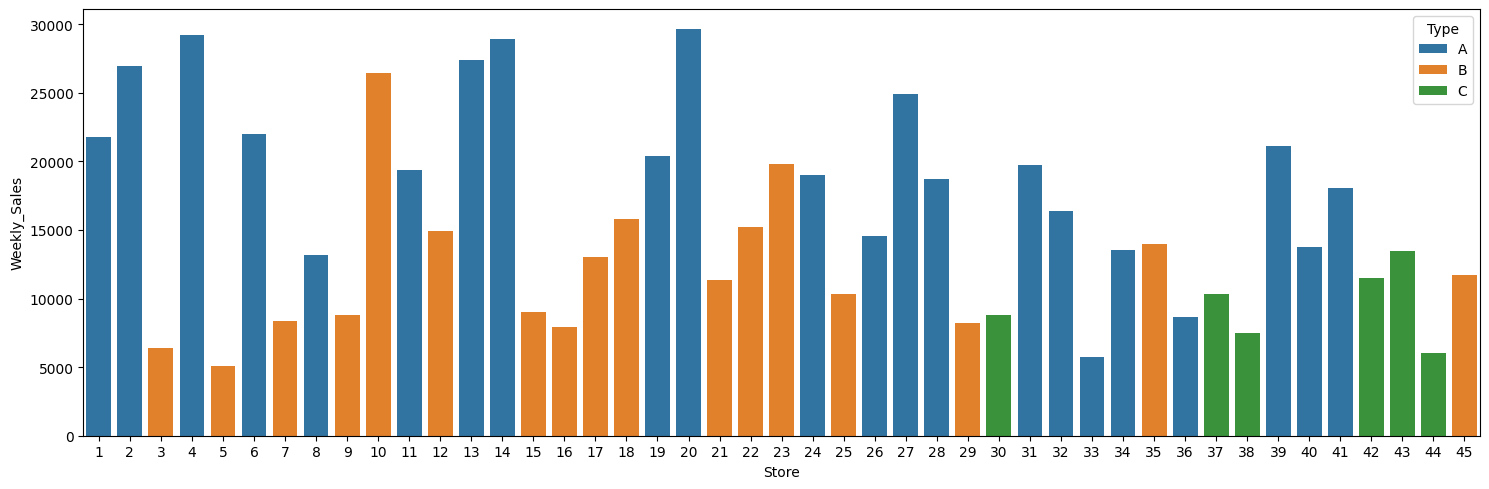

In [25]:
plt.figure(figsize=(15, 5))
sns.barplot(data=df_train, x='Store', y='Weekly_Sales', hue='Type', errorbar=None)
plt.tight_layout()  # To automatically adjust overlap
plt.show()

In [26]:
df_train.groupby('Type')['Weekly_Sales'].mean().round(2)

,Weekly_Sales
Type,
A,20145.11
B,12288.13
C,9547.43


In [27]:
df_train.groupby('Type')['Size'].mean().round(0)

,Size
Type,
A,182226.0
B,101798.0
C,40536.0


In [28]:
dept_sales = df_train.groupby('Dept')['Weekly_Sales'].mean().round(2)
print("TOP 5 HIGHEST EARNING DEPARTMENTS")
print(dept_sales.nlargest(5))
print("\nBOTTOM 5 LOWEST EARNING DEPARTMENTS")
print(dept_sales.nsmallest(5))

TOP 5 HIGHEST EARNING DEPARTMENTS
Dept
92    75204.87
95    69824.42
38    61090.62
72    50852.99
65    45441.71
Name: Weekly_Sales, dtype: float64

BOTTOM 5 LOWEST EARNING DEPARTMENTS
Dept
43     1.19
78    10.23
39    11.12
51    22.65
45    23.80
Name: Weekly_Sales, dtype: float64


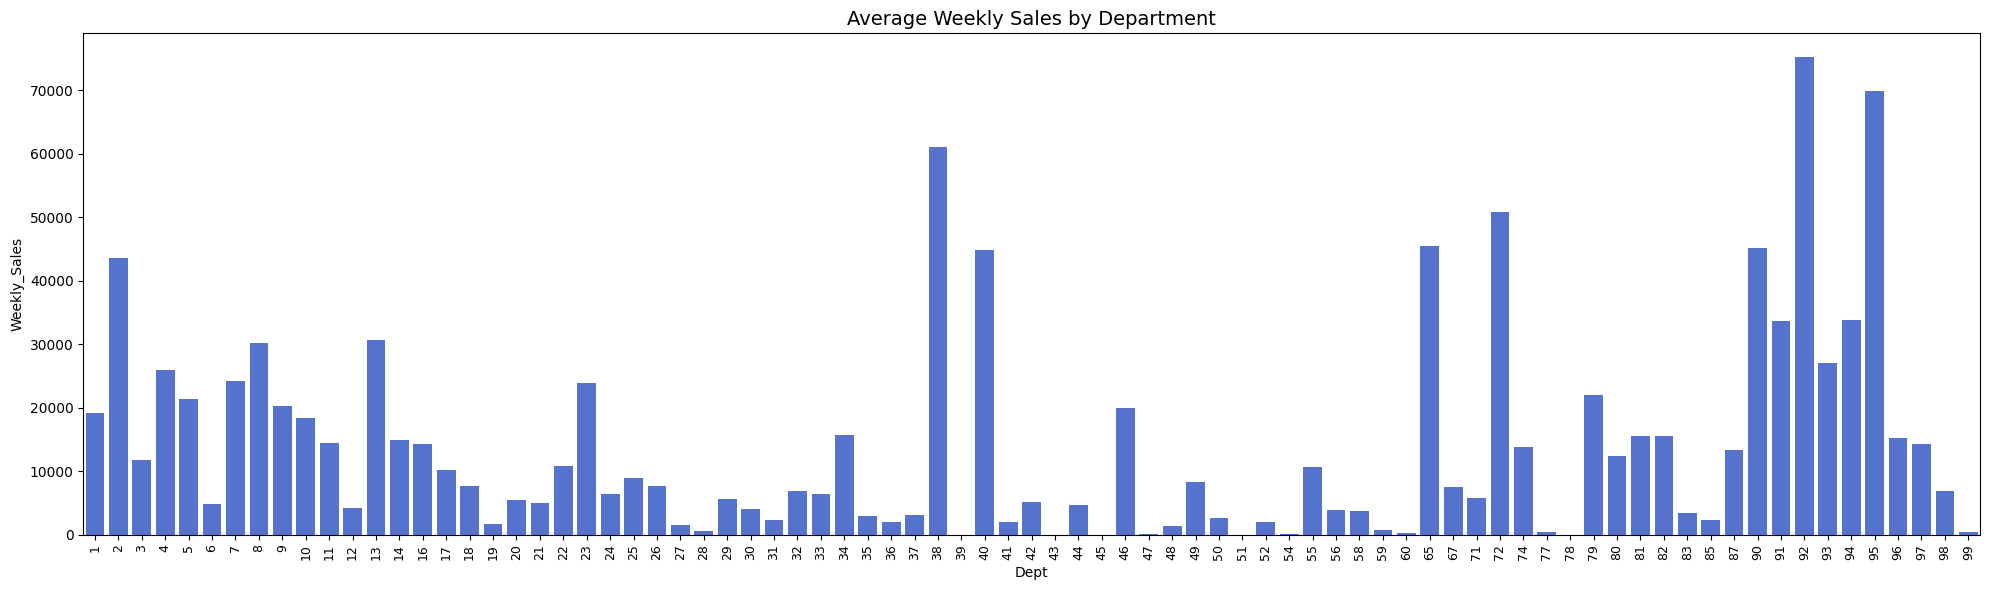

In [29]:
plt.figure(figsize=(20, 6))
sns.barplot(data=df_train, x='Dept', y='Weekly_Sales', errorbar=None, color='royalblue')
plt.xticks(rotation=90, fontsize=9)  # Rotate labels to prevent overlap
plt.title('Average Weekly Sales by Department', fontsize=14)
plt.tight_layout()
plt.show()

In [30]:
df_train['MarkDown_IsMissing'] = df_train['MarkDown1'].isnull()

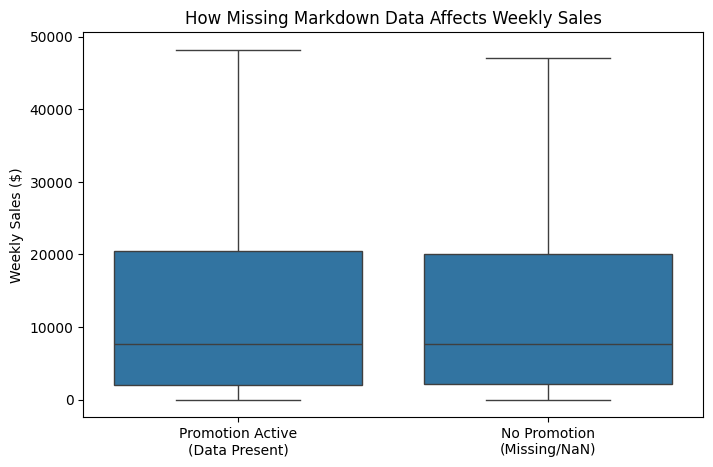

In [31]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_train, x='MarkDown_IsMissing', y='Weekly_Sales', showfliers=False)

plt.xticks([0, 1], ['Promotion Active\n(Data Present)', 'No Promotion\n(Missing/NaN)'])
plt.title('How Missing Markdown Data Affects Weekly Sales', fontsize=12)
plt.ylabel('Weekly Sales ($)')
plt.xlabel('')
plt.show()

In [32]:
df_train.drop(columns=['MarkDown_IsMissing'], inplace=True)

In [33]:
df_train.isna().sum()

,0
Store,0
Dept,0
Date,0
Weekly_Sales,0
IsHoliday,0
Temperature,0
Fuel_Price,0
MarkDown1,270085
MarkDown2,309367
MarkDown3,283618


In [34]:
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']

# Temporary DataFrame showing True where data exists, False where it is NaN
df_presence = df_train[markdown_cols].notnull()

# Add the IsHoliday column to it so we can group
df_presence['IsHoliday'] = df_train['IsHoliday']

# Calculate the percentage of time promotions are active
(df_presence.groupby('IsHoliday').mean() * 100).round(2)

,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5
IsHoliday,,,,,
False,35.40,25.65,32.06,31.63,35.57
True,40.26,36.15,38.62,36.98,40.43


Missing values in the markdown columns simply mean 0 because these promotional discounts are seasonal and do not run every week, so a missing value indicates that no markdown promotion was active during that specific time period.

In [35]:
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
df_train[markdown_cols] = df_train[markdown_cols].fillna(0)

In [36]:
df_train.isna().sum()

,0
Store,0
Dept,0
Date,0
Weekly_Sales,0
IsHoliday,0
Temperature,0
Fuel_Price,0
MarkDown1,0
MarkDown2,0
MarkDown3,0


In [37]:
macro_cols = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
correlation = df_train[macro_cols].corr()

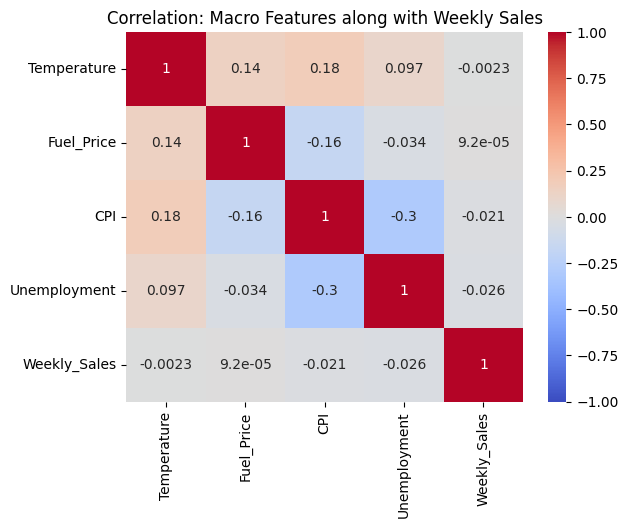

In [38]:
cols = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Weekly_Sales']
correlation = df_train[cols].corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation: Macro Features along with Weekly Sales')
plt.show()

External factors like weather, fuel, inflation, and unemployment have almost zero correlation with weekly sales, meaning these macro conditions do not drive or impact customer spending patterns.

Feature Engineering

In [39]:
df_train = df_train.sort_values(by=['Store', 'Dept', 'Date']).reset_index(drop=True)

# Encoding Categorical Features

In [40]:
type_map = {'A': 0, 'B': 1, 'C': 2}
df_train['Type'] = df_train['Type'].map(type_map)

In [41]:
df_train['IsHoliday'] = df_train['IsHoliday'].astype(int)

In [42]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error

In [43]:
# Sorting the data by Date to ensure chronological order
df_train = df_train.sort_values('Date').reset_index(drop=True)

In [44]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420285 entries, 0 to 420284
Data columns (total 19 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         420285 non-null  int64         
 1   Dept          420285 non-null  int64         
 2   Date          420285 non-null  datetime64[ns]
 3   Weekly_Sales  420285 non-null  float64       
 4   IsHoliday     420285 non-null  int64         
 5   Temperature   420285 non-null  float64       
 6   Fuel_Price    420285 non-null  float64       
 7   MarkDown1     420285 non-null  float64       
 8   MarkDown2     420285 non-null  float64       
 9   MarkDown3     420285 non-null  float64       
 10  MarkDown4     420285 non-null  float64       
 11  MarkDown5     420285 non-null  float64       
 12  CPI           420285 non-null  float64       
 13  Unemployment  420285 non-null  float64       
 14  Type          420285 non-null  int64         
 15  Size          420

In [45]:
features = [
    'Store', 'Dept', 'IsHoliday', 'Temperature', 'Fuel_Price',
    'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5',
    'CPI', 'Unemployment', 'Type', 'Size', 'Year', 'Month', 'Week'
]
X = df_train[features]
y = df_train['Weekly_Sales']

In [46]:
# Time-Based Split (80% Train, 20% Test)
split_index = int(len(df_train) * 0.80)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

In [47]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# MODEL 1: Linear Regression

In [48]:
# MODEL 1: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)
print(f"Linear Regression MAE: {mean_absolute_error(y_test, lr_preds):.2f}")

Linear Regression MAE: 14693.64


### Linear Regression is too simple for retail dynamics
Linear Regression is trying to draw a straight line through your data. However, retail sales are heavily driven by non-linear factors like seasonality (e.g., massive sales spikes during Thanksgiving and Christmas). Linear Regression completely flattens out these holiday spikes and averages everything out, leading to a high MAE.

In [49]:
X_train_sample = X_train_scaled[:10000]
y_train_sample = y_train.iloc[:10000]

# MODEL 2: KNN Regressor

In [50]:
# MODEL 2: KNN Regressor
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train_sample, y_train_sample)
knn_preds = knn_model.predict(X_test_scaled)
print(f"KNN MAE: {mean_absolute_error(y_test, knn_preds):.2f}")

KNN MAE: 13835.71


### KNN is struggling with "The Curse of Dimensionality"
KNN predicts by looking at the 5 most similar historical weeks. However, because our dataset has 17 different columns, the model gets confused. It ends up matching weeks that have similar weather or gas prices rather than prioritizing the exact Store and Department, which matter the most for sales. Increasing the number of neighbors ($k$) won't fix this because it just forces the model to average out even more unrelated weeks, making the predictions less accurate.

In [51]:
X_test_svm_sample = X_test_scaled[:2000]
y_test_svm_sample = y_test.iloc[:2000]

# MODEL 3: SVM

In [52]:
# MODEL 3: SVM
svm_model = SVR(kernel='rbf')
svm_model.fit(X_train_sample, y_train_sample)
svm_preds = svm_model.predict(X_test_svm_sample)
print(f"SVM MAE: {mean_absolute_error(y_test_svm_sample, svm_preds):.2f}")

SVM MAE: 13657.44


### Why SVM is Struggling
Support Vector Regression (SVR) is normally great at finding complex patterns, but it is mathematically too heavy for a dataset this large. Because it would freeze my computer to run all 420,000+ rows, I had to train it on a tiny random sample of just 10,000 rows. This means the model only saw about 2% of the total data, causing it to completely miss out on the specific trends, seasonal spikes, and history of the vast majority of our stores and departments.

## Feature Engineering

In [53]:
# The 1-week sales lag within each specific store and department
df_train['Sales_Lag_1'] = df_train.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(1)

In [54]:
# Store Size multiplied by the Holiday
df_train['Size_x_Holiday'] = df_train['Size'] * df_train['IsHoliday']

In [55]:
# Drop rows at the very beginning of the timeline that don't have a "last week"
df_train = df_train.dropna().reset_index(drop=True)

## Model 4: Random Forest

---



In [56]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [57]:
features = [
    'Store', 'Dept', 'IsHoliday', 'Temperature', 'Fuel_Price',
    'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5',
    'CPI', 'Unemployment', 'Type', 'Size', 'Year', 'Month', 'Week',
    'Sales_Lag_1', 'Size_x_Holiday'
]
X = df_train[features]
y = df_train['Weekly_Sales']

In [58]:
split_index = int(len(df_train) * 0.80)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

In [60]:
rf_baseline = RandomForestRegressor(n_estimators=50, max_depth=12, random_state=42, n_jobs=-1)
rf_baseline.fit(X_train, y_train)

rf_base_preds = rf_baseline.predict(X_test)
rf_base_mae = mean_absolute_error(y_test, rf_base_preds)
rf_base_rmse = np.sqrt(mean_squared_error(y_test, rf_base_preds))
rf_base_r2 = r2_score(y_test, rf_base_preds)

print(f"MAE:  {rf_base_mae:.2f}")
print(f"RMSE: {rf_base_rmse:.2f}")
print(f"R² Score: {rf_base_r2:.4f}")

MAE:  1596.92
RMSE: 3432.35
R² Score: 0.9757


In [63]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

In [65]:
rf_param_dist = {
    'n_estimators': [50, 80],
    'max_depth': [12, 16],
    'min_samples_split': [2, 5]
}

# TimeSeriesSplit (3 splits ensures no future data leaks into the past)
tscv = TimeSeriesSplit(n_splits=3)

print("Starting Time-Series Hyperparameter Tuning for Random Forest...")
rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=3,
    scoring='neg_mean_absolute_error',
    cv=tscv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

best_rf_model = rf_search.best_estimator_
rf_tuned_preds = best_rf_model.predict(X_test)

print("=== Tuned Random Forest Performance (Time-Series Validated) ===")
print(f"Best Parameters: {rf_search.best_params_}")
print(f"MAE:  {mean_absolute_error(y_test, rf_tuned_preds):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, rf_tuned_preds)):.2f}")
print(f"R² Score: {r2_score(y_test, rf_tuned_preds):.4f}")

Starting Time-Series Hyperparameter Tuning for Random Forest...
Fitting 3 folds for each of 3 candidates, totalling 9 fits
=== Tuned Random Forest Performance (Time-Series Validated) ===
Best Parameters: {'n_estimators': 80, 'min_samples_split': 2, 'max_depth': 12}
MAE:  1593.70
RMSE: 3430.02
R² Score: 0.9757


## Model 5: XGBoost

In [66]:
from xgboost import XGBRegressor

In [68]:
xgb_baseline = XGBRegressor(tree_method='hist', device='cuda', random_state=42)
xgb_baseline.fit(X_train, y_train)

# Predictions & Evaluation
xgb_base_preds = xgb_baseline.predict(X_test)
xgb_base_mae = mean_absolute_error(y_test, xgb_base_preds)
xgb_base_rmse = np.sqrt(mean_squared_error(y_test, xgb_base_preds))
xgb_base_r2 = r2_score(y_test, xgb_base_preds)

print(f"MAE:  {xgb_base_mae:.2f}")
print(f"RMSE: {xgb_base_rmse:.2f}")
print(f"R² Score: {xgb_base_r2:.4f}")

MAE:  1729.84
RMSE: 3469.34
R² Score: 0.9751


In [69]:
xgb_param_dist = {
    'n_estimators': [100, 200, 300],         # Number of sequential trees
    'max_depth': [6, 8, 10],                  # Depth limits for tree interaction
    'learning_rate': [0.03, 0.05, 0.1],      # Step size shrinkage
    'subsample': [0.7, 0.8, 0.9],            # Percentage of rows sampled per tree
    'colsample_bytree': [0.7, 0.8, 0.9]      # Percentage of features sampled per tree
}

# TimeSeriesSplit to protect chronological order
tscv = TimeSeriesSplit(n_splits=3)

print("Starting Time-Series Hyperparameter Tuning for XGBoost on GPU...")
xgb_search = RandomizedSearchCV(
    estimator=XGBRegressor(tree_method='hist', device='cuda', random_state=42),
    param_distributions=xgb_param_dist,
    n_iter=8,                            # More iterations because GPU execution is fast
    scoring='neg_mean_absolute_error',
    cv=tscv,                             # Chronological validation
    verbose=1,
    random_state=42
)

xgb_search.fit(X_train, y_train)

best_xgb_model = xgb_search.best_estimator_
xgb_tuned_preds = best_xgb_model.predict(X_test)

print("\n=== Tuned XGBoost Performance (Time-Series Validated) ===")
print(f"Best Parameters: {xgb_search.best_params_}")
print(f"MAE:  {mean_absolute_error(y_test, xgb_tuned_preds):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, xgb_tuned_preds)):.2f}")
print(f"R² Score: {r2_score(y_test, xgb_tuned_preds):.4f}")

Starting Time-Series Hyperparameter Tuning for XGBoost on GPU...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

=== Tuned XGBoost Performance (Time-Series Validated) ===
Best Parameters: {'subsample': 0.9, 'n_estimators': 300, 'max_depth': 10, 'learning_rate': 0.05, 'colsample_bytree': 0.9}
MAE:  1547.79
RMSE: 3160.38
R² Score: 0.9794


/tmp/ipykernel_873/2364705020.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


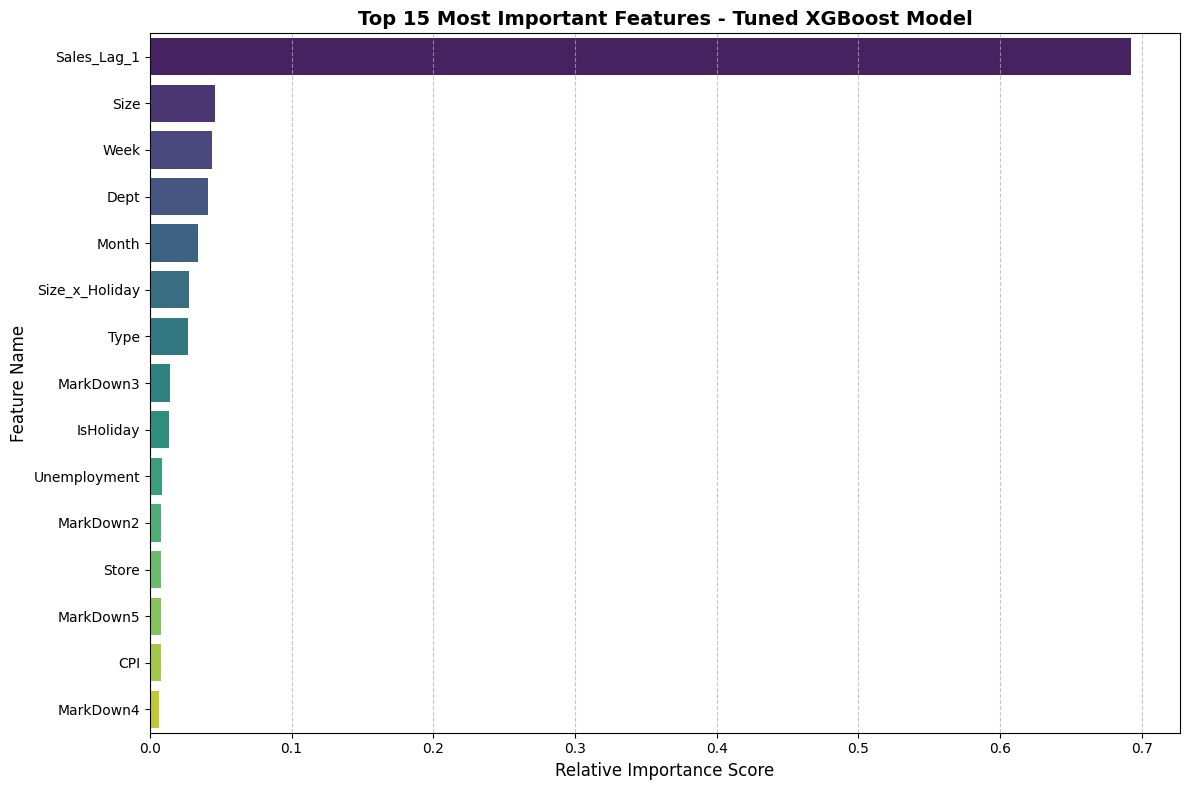

Top 15 Feature Importances
       Feature  Importance
   Sales_Lag_1    0.692386
          Size    0.045747
          Week    0.043531
          Dept    0.041259
         Month    0.034138
Size_x_Holiday    0.027569
          Type    0.026629
     MarkDown3    0.014333
     IsHoliday    0.013249
  Unemployment    0.008256
     MarkDown2    0.008150
         Store    0.008145
     MarkDown5    0.007787
           CPI    0.007614
     MarkDown4    0.006076


In [70]:
# Understanding Feature Importance
importances = best_xgb_model.feature_importances_
feature_names = X_train.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

plt.figure(figsize=(12, 8))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df.head(15),
    palette='viridis'
)

plt.title('Top 15 Most Important Features - Tuned XGBoost Model', fontsize=14, fontweight='bold')
plt.xlabel('Relative Importance Score', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Top 15 Feature Importances")
print(importance_df.head(15).to_string(index=False))

In [71]:
from sklearn.preprocessing import MinMaxScaler

In [73]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

def create_sequences(X, y, time_steps=4):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

TIME_STEPS = 4
X_train_3D, y_train_3D = create_sequences(X_train_scaled, y_train_scaled, TIME_STEPS)
X_test_3D, y_test_3D = create_sequences(X_test_scaled, y_test_scaled, TIME_STEPS)

print(f"Train Shape: {X_train_3D.shape}")
print(f"Test Shape: {X_test_3D.shape}")

Train Shape: (333565, 4, 19)
Test Shape: (83389, 4, 19)


In [74]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("GPU Active Devices:", tf.config.list_physical_devices('GPU'))

gru_model = Sequential([
    GRU(64, activation='tanh', return_sequences=True, input_shape=(X_train_3D.shape[1], X_train_3D.shape[2])),
    Dropout(0.2),

    GRU(32, activation='tanh', return_sequences=False),
    Dropout(0.2),

    Dense(16, activation='relu'),
    Dense(1)
])

gru_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mae'
)

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("\nTraining GRU Network on GPU...")
history = gru_model.fit(
    X_train_3D, y_train_3D,
    epochs=25,
    batch_size=512,
    validation_data=(X_test_3D, y_test_3D),
    callbacks=[early_stop],
    verbose=1
)

GPU Active Devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Training GRU Network on GPU...
Epoch 1/25
652/652 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.0207 - val_loss: 0.0192
Epoch 2/25
652/652 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0194 - val_loss: 0.0192
Epoch 3/25
652/652 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0194 - val_loss: 0.0192
Epoch 4/25
652/652 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0194 - val_loss: 0.0192
Epoch 5/25
652/652 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0194 - val_loss: 0.0192
Epoch 6/25
652/652 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0194 - val_loss: 0.0192
Epoch 7/25
652/652 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.0194 - val_loss: 0.0192
Epoch 8/25
652/652 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0194 - val_loss: 0.0192
Epoch 9/25
652/652 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0194 - val_loss: 0.0192
Epoch 10/25
652/652 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0194 - val_loss: 0.0192
Epoch 11/25
652/652 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0194 - val_loss: 0.0192


In [75]:
gru_preds_scaled = gru_model.predict(X_test_3D)

gru_preds = scaler_y.inverse_transform(gru_preds_scaled)
y_test_actual = scaler_y.inverse_transform(y_test_3D)

gru_mae = mean_absolute_error(y_test_actual, gru_preds)
gru_rmse = np.sqrt(mean_squared_error(y_test_actual, gru_preds))
gru_r2 = r2_score(y_test_actual, gru_preds)

print(f"MAE:  ${gru_mae:.2f}")
print(f"RMSE: ${gru_rmse:.2f}")
print(f"R² Score: {gru_r2:.4f}")

2606/2606 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step
MAE:  $13287.77
RMSE: $23520.49
R² Score: -0.1429


In [76]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

y_train_log = np.log1p(y_train.values)
y_test_log = np.log1p(y_test.values)

scaler_X = MinMaxScaler()
scaler_y_log = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled_log = scaler_y_log.fit_transform(y_train_log.reshape(-1, 1))
y_test_scaled_log = scaler_y_log.transform(y_test_log.reshape(-1, 1))

def create_sequences(X, y, time_steps=4):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

TIME_STEPS = 4
X_train_3D, y_train_3D = create_sequences(X_train_scaled, y_train_scaled_log, TIME_STEPS)
X_test_3D, y_test_3D = create_sequences(X_test_scaled, y_test_scaled_log, TIME_STEPS)

In [77]:
log_gru_model = Sequential([
    GRU(64, activation='tanh', return_sequences=True, input_shape=(X_train_3D.shape[1], X_train_3D.shape[2])),
    Dropout(0.2),
    GRU(32, activation='tanh', return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

log_gru_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mae')

print("Retraining Log-Transformed GRU on GPU...")
log_gru_model.fit(
    X_train_3D, y_train_3D,
    epochs=10,        # Kept short for time efficiency
    batch_size=512,
    validation_data=(X_test_3D, y_test_3D),
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Retraining Log-Transformed GRU on GPU...
Epoch 1/10
652/652 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.1208 - val_loss: 0.1141
Epoch 2/10
652/652 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.1102 - val_loss: 0.1132
Epoch 3/10
652/652 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.1098 - val_loss: 0.1132
Epoch 4/10
652/652 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.1098 - val_loss: 0.1134
Epoch 5/10
652/652 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.1098 - val_loss: 0.1133
Epoch 6/10
652/652 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.1098 - val_loss: 0.1132
Epoch 7/10
652/652 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.1098 - val_loss: 0.1132
Epoch 8/10
652/652 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 0.1098 - val_loss: 0.1132
Epoch 9/10
652/652 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.1098 - val_loss: 0.1136
Epoch 10/10
652/652 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.1098 - val_loss: 0.1132


In [78]:
preds_scaled_log = log_gru_model.predict(X_test_3D)

preds_log = scaler_y_log.inverse_transform(preds_scaled_log)
actual_log = scaler_y_log.inverse_transform(y_test_3D)

gru_final_preds = np.expm1(preds_log)
y_test_final_actual = np.expm1(actual_log)

log_gru_mae = mean_absolute_error(y_test_final_actual, gru_final_preds)
log_gru_rmse = np.sqrt(mean_squared_error(y_test_final_actual, gru_final_preds))
log_gru_r2 = r2_score(y_test_final_actual, gru_final_preds)

print("\nLog-Transformed GRU Final Performance")
print(f"MAE:  ${log_gru_mae:.2f}")
print(f"RMSE: ${log_gru_rmse:.2f}")
print(f"R² Score: {log_gru_r2:.4f}")

2606/2606 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step

Log-Transformed GRU Final Performance
MAE:  $13289.99
RMSE: $23467.24
R² Score: -0.1377


XGBoost won because it excels at handling mixed table data (like specific Stores and Departments) and isn't distracted by huge holiday sales spikes, whereas the GRU got overwhelmed trying to find a single time pattern across a massive, mixed dataset.

In [79]:
# Final Model

print("Training final champion model on 100% of available training data...")

final_xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=10,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    tree_method='hist',
    device='cuda',
    random_state=42
)

final_xgb_model.fit(X, y)

Training final champion model on 100% of available training data...


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9, device='cuda', early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [81]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115064 entries, 0 to 115063
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         115064 non-null  int64         
 1   Dept          115064 non-null  int64         
 2   Date          115064 non-null  datetime64[ns]
 3   IsHoliday     115064 non-null  bool          
 4   Temperature   115064 non-null  float64       
 5   Fuel_Price    115064 non-null  float64       
 6   MarkDown1     114915 non-null  float64       
 7   MarkDown2     86437 non-null   float64       
 8   MarkDown3     105235 non-null  float64       
 9   MarkDown4     102176 non-null  float64       
 10  MarkDown5     115064 non-null  float64       
 11  CPI           76902 non-null   float64       
 12  Unemployment  76902 non-null   float64       
 13  Type          115064 non-null  object        
 14  Size          115064 non-null  int64         
 15  Year          115

In [87]:
df_test['CPI'] = df_test['CPI'].fillna(df_train['CPI'].median())
df_test['Unemployment'] = df_test['Unemployment'].fillna(df_train['Unemployment'].median())
for i in range(1, 6):
    df_test[f'MarkDown{i}'] = df_test[f'MarkDown{i}'].fillna(0)

type_mapping = {'A': 1, 'B': 2, 'C': 3}
df_test['Type'] = df_test['Type'].map(type_mapping).fillna(1)

df_test['Size_x_Holiday'] = df_test['Size'] * df_test['IsHoliday'].astype(int)
df_test['IsHoliday'] = df_test['IsHoliday'].astype(int)

last_known_sales = df_train.groupby(['Store', 'Dept'])['Weekly_Sales'].last().reset_index()
last_known_sales.rename(columns={'Weekly_Sales': 'Sales_Lag_1'}, inplace=True)

df_test = pd.merge(df_test, last_known_sales, on=['Store', 'Dept'], how='left')
df_test['Sales_Lag_1'] = df_test['Sales_Lag_1'].fillna(df_train['Weekly_Sales'].median())

feature_columns = list(X_train.columns)
X_test_final = df_test[feature_columns]

final_predictions = final_xgb_model.predict(X_test_final)

In [84]:
df_sample=pd.read_csv('sampleSubmission.csv')

In [85]:
df_sample.head()

,Id,Weekly_Sales
0,1_1_2012-11-02,0
1,1_1_2012-11-09,0
2,1_1_2012-11-16,0
3,1_1_2012-11-23,0
4,1_1_2012-11-30,0


In [88]:
df_sample['Weekly_Sales'] = final_predictions
print(df_sample.head())
df_sample.to_csv('final_submission.csv', index=False)

               Id  Weekly_Sales
0  1_1_2012-11-02  29112.300781
1  1_1_2012-11-09  20276.310547
2  1_1_2012-11-16  26719.777344
3  1_1_2012-11-23  35428.851562
4  1_1_2012-11-30  28027.574219


### Model Evaluation and Justification

#### Evaluation Metrics
Mean Absolute Error (MAE): MAE measures the average absolute magnitude of errors directly in real, everyday dollar values. By treating all errors linearly, it provides an intuitive baseline for calculating day-to-day operational planning accuracy, assessing general inventory holding costs, and managing baseline store budgeting.
Root Mean Squared Error (RMSE): RMSE squares errors before averaging them, making it exceptionally sensitive to large outliers. In this forecasting problem, it functions as an essential "risk check"; a major gap between your MAE and RMSE scores reveals whether the model is making rare but massive over- or under-predictions during critical windows that could cripple warehouse logistics.


#### Time-Series-Aware Validation Strategy
Implementing a standard, random $K$-Fold cross-validation strategy is fundamentally incorrect for time-series modeling due to temporal data leakage. Random splitting shuffles records across time, allowing the model to train on future data (e.g., Black Friday 2012) to predict past events (e.g., a normal week in 2011). This violates the core constraint of production forecasting, creating an artificial, over-optimistic validation score that completely collapses when deployed to predict the actual future.To prevent this look-ahead bias, an Expanding Window TimeSeriesSplit is utilized.

In [89]:
import xgboost as xgb
import pandas as pd
import numpy as np
import sklearn

print(f"xgboost=={xgb.__version__}")
print(f"pandas=={pd.__version__}")
print(f"numpy=={np.__version__}")
print(f"scikit-learn=={sklearn.__version__}")

xgboost==3.3.0
pandas==2.2.2
numpy==2.0.2
scikit-learn==1.6.1
